In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import scarf
from scarf import cytebase
from scarf.plotting import CellField, NormalizationSpec

scarf.configure_output(level="WARNING", progress=False)
# HF retry messages include private bucket URLs; keep them out of shared outputs.
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
catalog = cytebase.Catalog()  # Public Cytebase unless CYTEBASE_BUCKET is set.

In [2]:
ready = catalog.find_datasets(ready_only=True)
ready

| Cytebase ID | Status | Cells | Genes | Tissues | Diseases |
| --- | --- | ---: | ---: | --- | --- |
| cao&#95;2020&#95;survey&#95;human&#95;embryonic&#95;development&#95;f7c1c579 | ready | 4,062,980 | 45,676 | adrenal gland, cerebellum, eye, heart, intestine, kidney, liver, lung, muscle organ, pancreas, plac… | normal, trisomy 18 |
| sikkema&#95;2023&#95;integrated&#95;cell&#95;atlas&#95;human&#95;lung&#95;health&#95;disease&#95;full&#95;9f222629 | ready | 2,282,447 | 55,329 | lung, lung parenchyma, nose, respiratory airway | COVID-19, chronic obstructive pulmonary disease, chronic rhinitis, cystic fibrosis, hypersensitivit… |
| ren&#95;2021&#95;large&#95;scale&#95;single&#95;cell&#95;covid&#95;19&#95;patients&#95;9dbab10c | ready | 1,462,702 | 27,131 | blood, lung, saliva | COVID-19, normal |
| salcher&#95;2022&#95;single&#95;cell&#95;lung&#95;cancer&#95;atlas&#95;luca&#95;extended&#95;atlas&#95;1e6a6ef9 | ready | 1,283,972 | 17,764 | adrenal tissue, brain, liver, lung, lymph node, pleural effusion | chronic obstructive pulmonary disease, lung adenocarcinoma, non-small cell lung carcinoma, normal,… |
| perez&#95;2022&#95;multiplexed&#95;scrna&#95;1&#95;2&#95;million&#95;pbmcs&#95;adult&#95;lupus&#95;samples&#95;218acb0f | ready | 1,263,676 | 30,172 | blood | normal, systemic lupus erythematosus |
| yazar&#95;2022&#95;single&#95;cell&#95;eqtl&#95;mapping&#95;control&#95;autoimmune&#95;disease&#95;3faad104 | ready | 1,248,980 | 35,528 | blood | normal |
| tabula&#95;2022&#95;tabula&#95;sapiens&#95;all&#95;cells&#95;53d208b0 | ready | 1,136,218 | 60,606 | abdominal aorta, adipose tissue, anterior part of tongue, anterior segment of eyeball, aorta, ascen… | normal |
| litvinukova&#95;2020&#95;all&#95;cells&#95;adult&#95;human&#95;heart&#95;d4e69e01 | ready | 486,134 | 32,383 | apex of heart, heart left ventricle, heart right ventricle, interventricular septum, left cardiac a… | normal |
| natri&#95;2024&#95;single&#95;cell&#95;rna&#95;seq&#95;lung&#95;disease&#95;ild&#95;subtypes&#95;f14bc322 | ready | 471,905 | 31,432 | lung | anthracosis, hypersensitivity pneumonitis, interstitial lung disease, lymphoid interstitial pneumon… |
| tadross&#95;2025&#95;human&#95;hypomap&#95;single&#95;nucleus&#95;data&#95;a2c833f7 | ready | 433,369 | 36,924 | hypothalamus | normal |
| elmentaite&#95;2021&#95;total&#95;cells&#95;human&#95;mapped&#95;across&#95;space&#95;time&#95;80a2c5b6 | ready | 428,469 | 32,383 | cecum mucosa, colonic mucosa, duodenal mucosa, ileal mucosa, jejunal mucosa, mesenteric lymph node,… | Crohn disease, normal |
| steuernagel&#95;2022&#95;mouse&#95;hypomap&#95;unified&#95;murine&#95;hypothalamus&#95;dbb4e1ed | ready | 384,925 | 51,216 | hypothalamus | normal |
| lake&#95;2025&#95;single&#95;cell&#95;rna&#95;seq&#95;adult&#95;human&#95;kidney&#95;version&#95;2&#95;0&#95;91f31e05 | ready | 348,984 | 32,363 | kidney | acute kidney injury, chronic kidney disease, normal |
| dominguez&#95;conde&#95;2022&#95;global&#95;1b9d8702 | ready | 329,762 | 35,469 | blood, bone marrow, caecum, duodenum, ileum, jejunal epithelium, jejunum lamina propria, liver, lun… | normal |
| lake&#95;2025&#95;mouse&#95;single&#95;nucleus&#95;rna&#95;seq&#95;mouse&#95;kidney&#95;version&#95;2&#95;0&#95;9ac3d74d | ready | 315,764 | 28,564 | kidney | acute kidney injury, normal |
| hrovatin&#95;2023&#95;mouse&#95;mouse&#95;pancreatic&#95;islet&#95;including&#95;diabetes&#95;49e4ffcc | ready | 301,796 | 30,849 | islet of Langerhans, pancreas | endocrine pancreas disorder, normal, type 1 diabetes mellitus, type 2 diabetes mellitus |
| tabula&#95;2020&#95;mouse&#95;all&#95;single&#95;cell&#95;ageing&#95;tissues&#95;mouse&#95;10x&#95;48b37086 | ready | 245,389 | 17,943 | adipose tissue, bladder lumen, bone marrow, heart, kidney, large intestine, limb muscle, liver, lun… | normal |
| eraslan&#95;2022&#95;single&#95;nucleus&#95;cross&#95;disease&#95;gene&#95;function&#95;4ed927e9 | ready | 209,126 | 32,088 | anterior wall of left ventricle, breast, esophagus muscularis mucosa, gastrocnemius, lingula of lef… | normal |
| kamath&#95;2022&#95;human&#95;oligodendrocytes&#95;10x&#95;scrna&#95;5829c7ba | ready | 178,815 | 33,295 | substantia nigra pars compacta | Lewy body dementia, Parkinson disease, normal |
| guilliams&#95;2022&#95;all&#95;cells&#95;human&#95;liver&#95;dataset&#95;e84f2780 | ready | 167,598 | 30,172 | liver | normal |

Showing 20 of 45 rows. Use `to_markdown(max_rows=None)` to display all rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [3]:
matches = catalog.search("wilson kidney cortex", ready_only=True, max_cell_chars=None)
if not matches:
    raise RuntimeError("The example kidney dataset is not ready in this bucket")
matches

| Cytebase ID | Title | Cells | Tissues | Diseases |
| --- | --- | ---: | --- | --- |
| wilson&#95;2022&#95;human&#95;kidney&#95;cortex&#95;snrna&#95;diabetic&#95;kidney&#95;disease&#95;e067e5ca | Human kidney cortex snRNA-seq data from donors with and without diabetic kidney disease | 39,176 | cortex of kidney | normal, type 2 diabetes mellitus |

1 row.

In [4]:
dataset_id = matches[0]["cytebase_id"]
entry = catalog.dataset(dataset_id)
entry

### Human kidney cortex snRNA-seq data from donors with and without diabetic kidney disease

- **Cytebase ID:** `wilson_2022_human_kidney_cortex_snrna_diabetic_kidney_disease_e067e5ca`
- **Citation:**
    - Publication: https://doi.org/10.1038/s41467-022-32972-z
    - Dataset Version: https://datasets.cellxgene.cziscience.com/473d2e1c-a579-4682-96aa-b5b166d7b23e.h5ad
    - curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/b3e2c6e3-9b05-4da9-8f42-da38a664b45b
- **DOI:** 10.1038/s41467-022-32972-z
- **CELLxGENE:** https://cellxgene.cziscience.com/collections/b3e2c6e3-9b05-4da9-8f42-da38a664b45b
- **Explorer:** https://cellxgene.cziscience.com/e/e067e5ca-e53e-485f-aa8e-efd5435229c8.cxg/
- **Size:** 39,176 cells, 35,469 genes
- **Status:** ready
- **Organisms:** Homo sapiens
- **Assays:** 10x 3' v3, 10x 5' v1
- **Tissues:** cortex of kidney
- **Diseases:** normal, type 2 diabetes mellitus
- **Suspension:** nucleus
- **Source embeddings:** X_harmony, X_pca, X_umap

In [5]:
catalog.list_terms("disease")

| Label | Ontology ID | Datasets |
| --- | --- | ---: |
| COVID-19 | MONDO:0100096 | 2 |
| Crohn disease | MONDO:0005011 | 1 |
| Lewy body dementia | MONDO:0007488 | 7 |
| Parkinson disease | MONDO:0005180 | 7 |
| acute kidney injury | MONDO:0002492 | 3 |
| anthracosis | MONDO:0006654 | 1 |
| chronic kidney disease | MONDO:0005300 | 2 |
| chronic obstructive pulmonary disease | MONDO:0005002 | 2 |
| chronic rhinitis | MONDO:0004514 | 1 |
| cystic fibrosis | MONDO:0009061 | 1 |
| endocrine pancreas disorder | MONDO:0001933 | 1 |
| hypersensitivity pneumonitis | MONDO:0017853 | 2 |
| interstitial lung disease | MONDO:0015925 | 2 |
| lung adenocarcinoma | MONDO:0005061 | 2 |
| lung large cell carcinoma | MONDO:0003050 | 1 |
| lymphangioleiomyomatosis | MONDO:0011705 | 1 |
| lymphoid interstitial pneumonia | MONDO:0009537 | 1 |
| metabolic dysfunction-associated steatotic liver disease | MONDO:0013209 | 3 |
| non-small cell lung carcinoma | MONDO:0005233 | 1 |
| non-specific interstitial pneumonia | MONDO:0019622 | 2 |

Showing 20 of 30 rows. Use `to_markdown(max_rows=None)` to display all rows.

In [6]:
tissue = matches[0]["tissue_labels"][0]
catalog.find_datasets(tissue=tissue, organism="Homo sapiens", ready_only=True)

| Cytebase ID | Status | Cells | Genes | Tissues | Diseases |
| --- | --- | ---: | ---: | --- | --- |
| tabula&#95;2022&#95;tabula&#95;sapiens&#95;all&#95;cells&#95;53d208b0 | ready | 1,136,218 | 60,606 | abdominal aorta, adipose tissue, anterior part of tongue, anterior segment of eyeball, aorta, ascen… | normal |
| wilson&#95;2022&#95;human&#95;kidney&#95;cortex&#95;snrna&#95;diabetic&#95;kidney&#95;disease&#95;e067e5ca | ready | 39,176 | 35,469 | cortex of kidney | normal, type 2 diabetes mellitus |

2 rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [7]:
catalog.query(
    """
    SELECT cytebase_id, first_author, year, cell_count, n_genes,
           len(cell_type_labels) AS n_cell_types
    FROM datasets
    WHERE status = ? AND processed_version_id = latest_version_id
      AND zarr_uri IS NOT NULL
    ORDER BY cell_count
    LIMIT 10
    """,
    parameters=["ready"],
)

| Cytebase ID | First Author | Year | Cells | Genes | N Cell Types |
| --- | --- | ---: | ---: | ---: | --- |
| guilliams&#95;2022&#95;liver&#95;visium&#95;human&#95;h35&#95;sample1&#95;a23220e5 | Guilliams | 2,022 | 4,992 | 30,304 | 10 |
| guilliams&#95;2022&#95;liver&#95;visium&#95;human&#95;h35&#95;sample2&#95;a15f5757 | Guilliams | 2,022 | 4,992 | 30,304 | 5 |
| guilliams&#95;2022&#95;liver&#95;visium&#95;human&#95;h36&#95;c8f188e9 | Guilliams | 2,022 | 4,992 | 30,304 | 13 |
| guilliams&#95;2022&#95;liver&#95;visium&#95;human&#95;h37&#95;3d784d25 | Guilliams | 2,022 | 4,992 | 30,304 | 11 |
| guilliams&#95;2022&#95;liver&#95;visium&#95;human&#95;h38&#95;b34177ad | Guilliams | 2,022 | 4,992 | 30,304 | 13 |
| guilliams&#95;2022&#95;mouse&#95;liver&#95;visium&#95;mouse&#95;sample&#95;cap002&#95;f4c14763 | Guilliams | 2,022 | 4,992 | 30,198 | 5 |
| guilliams&#95;2022&#95;mouse&#95;liver&#95;visium&#95;mouse&#95;sample&#95;jbo001&#95;41027c3b | Guilliams | 2,022 | 4,992 | 30,201 | 18 |
| guilliams&#95;2022&#95;mouse&#95;liver&#95;visium&#95;mouse&#95;sample&#95;jbo002&#95;91b9a882 | Guilliams | 2,022 | 4,992 | 30,201 | 16 |
| guilliams&#95;2022&#95;mouse&#95;liver&#95;visium&#95;mouse&#95;sample&#95;jbo003&#95;d9657735 | Guilliams | 2,022 | 4,992 | 30,201 | 17 |
| guilliams&#95;2022&#95;mouse&#95;liver&#95;visium&#95;mouse&#95;sample&#95;jbo004&#95;3146391a | Guilliams | 2,022 | 4,992 | 30,201 | 17 |

10 rows.

In [8]:
ds = catalog.open_datastore(entry.id)
ds

DataStore has 39176 (39176) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'assay', 'assay_ontology_term_id', 'author_cell_type', 
            'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 
            'disease_ontology_term_id', 'donor_id', 'doublet_id', 'is_primary_data', 'library_uuid', 
            'mapped_reference_annotation', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 
            'observation_joinid', 'percent.mt', 'percent.rpl', 'percent.rps', 'reported_diseases', 
            'sample_preservation_method', 'sample_uuid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'seurat_clusters', 
            'sex', 'sex_ontology_term_id', 'suspension_type', 'suspension_uuid', 'tissue', 
            'tissue_ontology_term_id', 'tissue_type'
   RNA assay has 35469 features 

In [9]:
print("Source embedding keys:", entry.source_embeddings())
print("Imported embedding keys:", sorted(cytebase.embeddings(ds)))
umap_ref = cytebase.embedding(ds, "X_umap")

Source embedding keys: ['X_harmony', 'X_pca', 'X_umap']


Imported embedding keys: ['X_umap']


In [10]:
wanted = ["cell_type", "tissue", "disease", "donor_id", "sex", "assay"]
columns = [column for column in wanted if column in ds.cells.columns]
meta = ds.cells.to_pandas_dataframe(["ids", *columns], key="I").set_index("ids")
meta.head()

,cell_type,tissue,disease,donor_id,sex,assay
ids,,,,,,
AAACCTGAGTGTTAGA-1,epithelial cell of proximal tubule,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCAAGCGCTC-1,kidney loop of Henle thick ascending limb epit...,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCACCAGATT-1,kidney loop of Henle thick ascending limb epit...,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCAGTCAGAG-1,epithelial cell of proximal tubule,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCATGGAATA-1,kidney distal convoluted tubule epithelial cell,cortex of kidney,normal,control_1,male,10x 5' v1


In [11]:
meta["cell_type"].value_counts().rename("cells").to_frame()

,cells
cell_type,
epithelial cell of proximal tubule,11478
kidney distal convoluted tubule epithelial cell,8469
kidney loop of Henle thick ascending limb epithelial cell,7749
renal principal cell,3295
renal alpha-intercalated cell,2029
endothelial cell,1702
parietal epithelial cell,1103
podocyte,1069
kidney loop of Henle thin ascending limb epithelial cell,679


In [12]:
if "disease" in meta:
    display(pd.crosstab(meta["cell_type"], meta["disease"]))

disease,normal,type 2 diabetes mellitus
cell_type,,
endothelial cell,1167,535
epithelial cell of proximal tubule,8818,2660
fibroblast,210,128
kidney distal convoluted tubule epithelial cell,6099,2370
kidney loop of Henle thick ascending limb epithelial cell,5432,2317
kidney loop of Henle thin ascending limb epithelial cell,324,355
leukocyte,54,156
mesangial cell,268,117
parietal epithelial cell,696,407


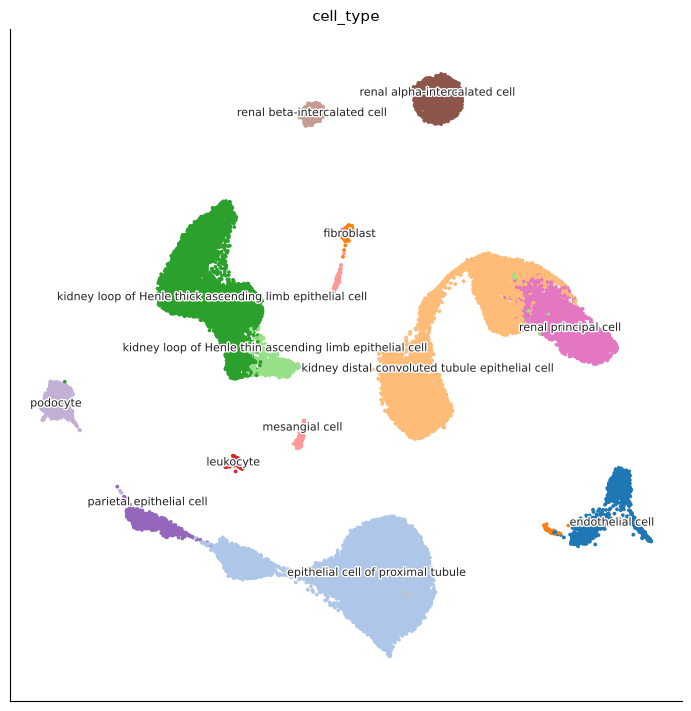

In [13]:
cell_type_plot = ds.plots.embedding(
    layout=umap_ref, color_by="cell_type", figsize=(10, 7)
)

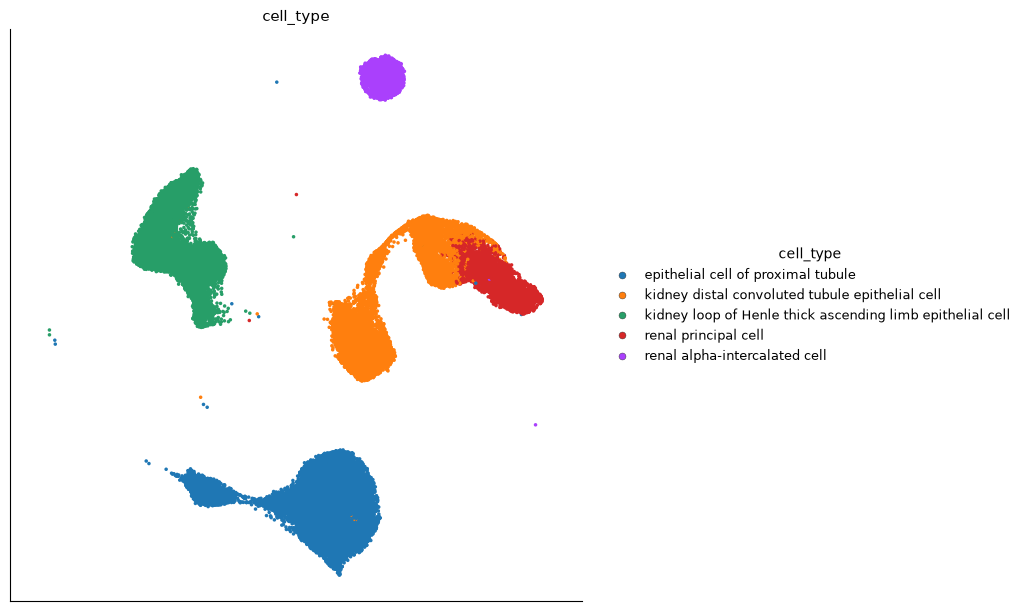

In [14]:
top_types = meta["cell_type"].value_counts().head(5).index.tolist()
ds.plots.embedding(
    layout=umap_ref, color_by="cell_type", groups=top_types, figsize=(10, 6)
);

In [15]:
requested_genes = ["UMOD", "SLC34A1", "NPHS1", "PECAM1"]
by_upper = {str(name).upper(): str(name) for name in ds.RNA.feats.fetch_all("names")}
genes = [by_upper[name.upper()] for name in requested_genes if name.upper() in by_upper]
print("Found:", genes)
print("Missing:", [name for name in requested_genes if name.upper() not in by_upper])

Found: ['UMOD', 'SLC34A1', 'NPHS1', 'PECAM1']
Missing: []


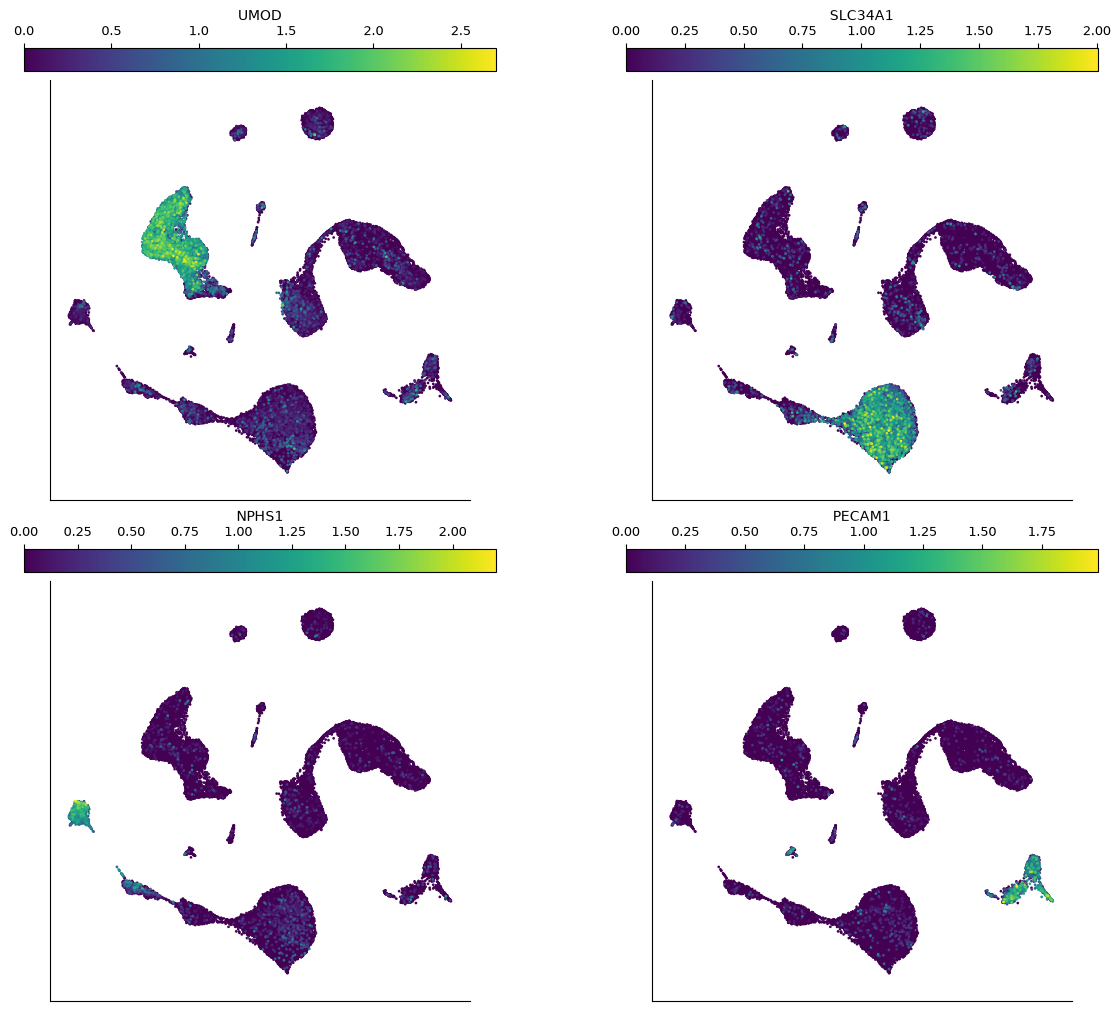

In [16]:
if genes:
    ds.plots.embedding(
        layout=umap_ref,
        color_by=genes,
        normalization=NormalizationSpec(transform="log1p"),
        sort_values=True,
        n_columns=2,
        figsize=(12, 10),
    );

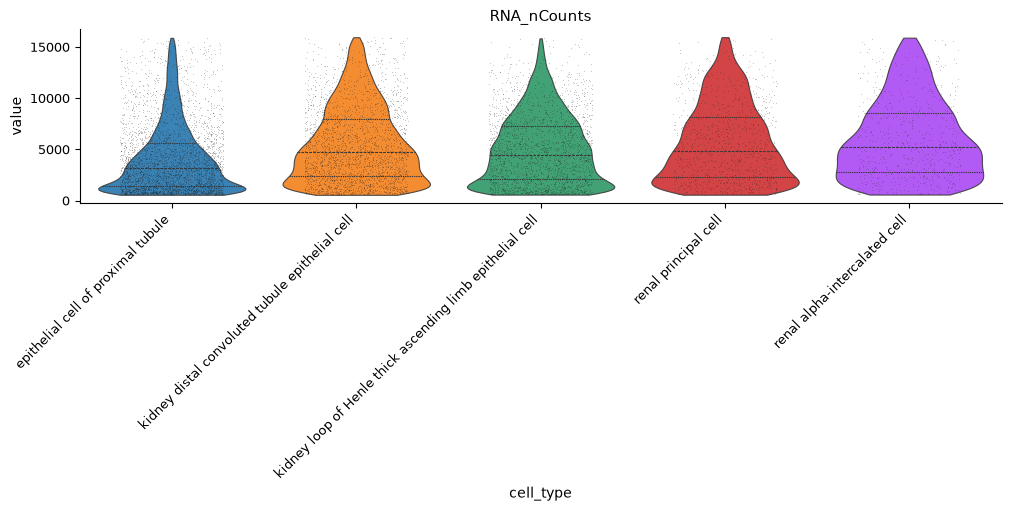

In [17]:
if "RNA_nCounts" in ds.cells.columns:
    ds.plots.distribution(
        "RNA_nCounts",
        grouping=CellField("cell_type"),
        groups=top_types,
        figsize=(10, 5),
    );

In [18]:
coords = cytebase.embedding_coordinates(ds, umap_ref)
frame = coords.join(meta)
frame.head()

,umap_1,umap_2,cell_type,tissue,disease,donor_id,sex,assay
ids,,,,,,,,
AAACCTGAGTGTTAGA-1,-0.523972,-8.470732,epithelial cell of proximal tubule,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCAAGCGCTC-1,-7.073731,3.068685,kidney loop of Henle thick ascending limb epit...,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCACCAGATT-1,-6.279858,4.984632,kidney loop of Henle thick ascending limb epit...,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCAGTCAGAG-1,0.838804,-11.116598,epithelial cell of proximal tubule,cortex of kidney,normal,control_1,male,10x 5' v1
AAACCTGCATGGAATA-1,3.573810,5.386316,kidney distal convoluted tubule epithelial cell,cortex of kidney,normal,control_1,male,10x 5' v1


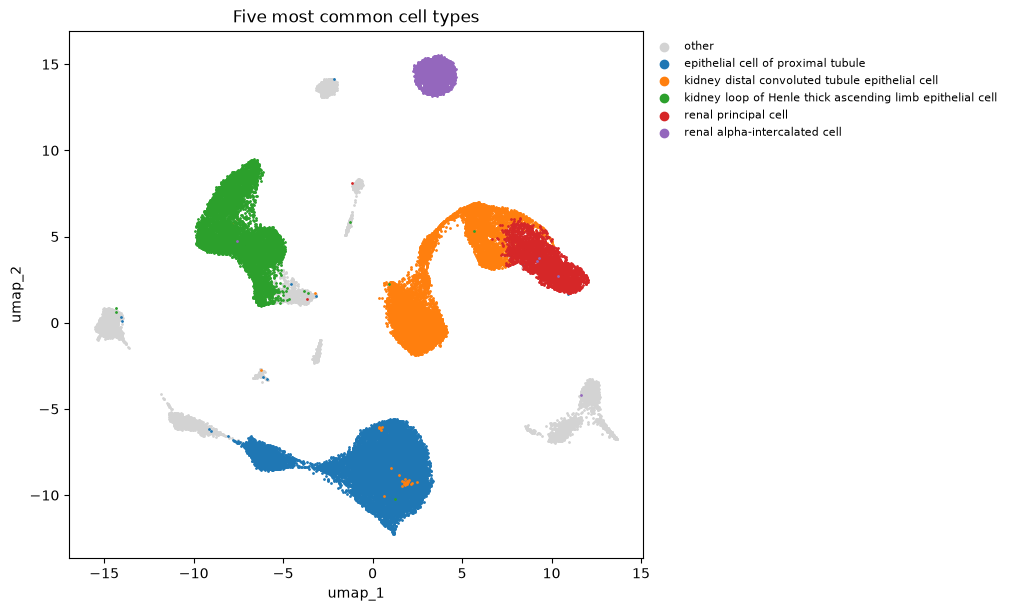

In [19]:
x, y = coords.columns[:2]
top = frame["cell_type"].value_counts().head(5).index
rest = frame[~frame["cell_type"].isin(top)]

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.scatter(rest[x], rest[y], s=1, c="lightgrey", label="other", rasterized=True)
for label in top:
    part = frame[frame["cell_type"] == label]
    ax.scatter(part[x], part[y], s=1, label=label, rasterized=True)
ax.set(xlabel=x, ylabel=y, title="Five most common cell types")
ax.legend(
    markerscale=6, fontsize=8, bbox_to_anchor=(1, 1), loc="upper left", frameon=False
)
plt.show()
plt.close(fig)

In [20]:
out = Path("figures")
out.mkdir(exist_ok=True)
cell_type_plot.save(out / "cytebase_cell_types.png", dpi=150)
cell_type_plot.close()
print("Saved figures/cytebase_cell_types.png")

Saved figures/cytebase_cell_types.png
